# Configurações Iniciais - instalação

In [42]:
pip install scipy

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------------ ------------------------- 20.5/60.8 kB 640.0 kB/s eta 0:00:01
     -------------------------------- ----- 51.2/60.8 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 647.7 kB/s eta 0:00:00
   ---------------------------------------- 0.0/40.9 MB ? eta -:--:--
   ---------------------------------------- 0.4/40.9 MB 8.9 MB/s eta 0:00:05
   -- ------------------------------------- 2.4/40.9 MB 25.3 MB/s eta 0:00:02
   --- ------------------------------------ 3.5/40.9 MB 31.6 MB/s eta 0:00:02
   -------- ------------------------------- 8.6/40.9 MB 45.6 MB/s eta 0:00:01
   ----------- ---------------------------- 11.7/40.9 MB 65.2 MB/s eta 0:00:01
   -------------- ------------------------- 14.7/40.9 MB 73.1 MB/s eta 0:00:01
   ----------------- ---------------------- 17.8/40.9 MB 65.6 MB/s eta 0:00:01
   -------------------- ------------------- 20.9/40.9 MB 65.6 MB/s eta


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Configurações iniciais - conexão Google Drive Planilhas

Autorização e autenticação da conexão com a conta do Google Drive.

Importação da planilha Google Sheets e conversão para DataFrame no Pandas:

In [12]:
#worksheet = gc.open('DadosInvestimentos').sheet1
import pandas as pd


df = pd.read_csv("light.csv")

df

,Unnamed: 0,Event,Date,EndTime,TimeControl,White,Black,WhiteElo,BlackElo,ECO,Result
0,0,Live Chess,2014.09.07,03:15:08,120+1,123lt,kingbos,1343,1129,D08,1-0
1,1,Live Chess,2014.09.07,03:18:59,120+1,betablokator,123lt,1266,1469,B21,0-1
2,2,Live Chess,2014.09.07,03:23:36,120+1,Computer3-HARD,123lt,1529,1592,D10,0-1
3,3,Live Chess,2014.09.07,03:26:27,120+1,123lt,Computer3-HARD,1577,1521,C41,1/2-1/2
4,4,Live Chess,2014.09.07,03:27:32,120+1,Computer3-HARD,123lt,1528,1491,D00,1-0
...,...,...,...,...,...,...,...,...,...,...,...
5399640,6113913,Live Chess,2021.04.20,01:14:49,60,zvonokchess1996,TampaChess,2892,2726,A45,1-0
5399641,6113914,Live Chess,2021.04.20,01:17:00,60,TampaChess,zvonokchess1996,2721,2899,C26,0-1
5399642,6113915,Live Chess,2021.04.20,01:19:13,60,zvonokchess1996,TampaChess,2906,2717,A52,1-0
5399643,6113916,Live Chess,2022.04.17,00:07:30,60,TampaChess,zvonokchess1996,2755,2932,C26,0-1


Ao verificar os tipos das colunas, percebemos que o tipo float não foi identificado automaticamente.

In [15]:
df.dtypes

Unnamed: 0      int64
Event          object
Date           object
EndTime        object
TimeControl    object
White          object
Black          object
WhiteElo        int64
BlackElo        int64
ECO            object
Result         object
dtype: object

Assim, Organizamos as colunas e realizamos conversões numericas:

In [22]:

split_result = df['Result'].str.split('-', expand=True)
print(split_result)
df['ResultWhite'] = split_result[0]
df['ResultBlack'] = split_result[1]
df['ResultBlack'] = pd.to_numeric(df['ResultBlack'],errors = 'coerce')
df['ResultWhite'] = pd.to_numeric(df['ResultWhite'],errors = 'coerce')
df['ResultWhite'] = df['ResultWhite'].fillna(0.5)
df['ResultBlack'] = df['ResultBlack'].fillna(0.5)
df.head(10)


           0    1
0          1    0
1          0    1
2          0    1
3        1/2  1/2
4          1    0
...      ...  ...
5399640    1    0
5399641    0    1
5399642    1    0
5399643    0    1
5399644    1    0

[5399645 rows x 2 columns]


,Unnamed: 0,Event,Date,EndTime,TimeControl,White,Black,WhiteElo,BlackElo,ECO,Result,ResultWhite,ResultBlack
0,0,Live Chess,2014.09.07,03:15:08,120+1,123lt,kingbos,1343,1129,D08,1-0,1.0,0.0
1,1,Live Chess,2014.09.07,03:18:59,120+1,betablokator,123lt,1266,1469,B21,0-1,0.0,1.0
2,2,Live Chess,2014.09.07,03:23:36,120+1,Computer3-HARD,123lt,1529,1592,D10,0-1,0.0,1.0
3,3,Live Chess,2014.09.07,03:26:27,120+1,123lt,Computer3-HARD,1577,1521,C41,1/2-1/2,0.5,0.5
4,4,Live Chess,2014.09.07,03:27:32,120+1,Computer3-HARD,123lt,1528,1491,D00,1-0,1.0,0.0
5,5,Live Chess,2014.09.07,03:29:28,120+1,123lt,Computer3-HARD,1561,1513,D30,1-0,1.0,0.0
6,6,Live Chess,2014.09.07,03:33:04,120+1,Computer3-HARD,123lt,1491,1609,B70,0-1,0.0,1.0
7,7,Live Chess,2014.09.07,03:37:32,120+1,123lt,Computer3-HARD,1542,1493,A56,0-1,0.0,1.0
8,8,Live Chess,2014.09.07,03:39:31,120+1,Computer3-HARD,123lt,1506,1538,C41,1/2-1/2,0.5,0.5
9,9,Live Chess,2014.09.07,03:42:54,60,123lt,Jake_McFly,1579,1516,D30,1-0,1.0,0.0


Reconfirmando após conversão forçada dos tipos:

In [20]:
df.dtypes

Unnamed: 0       int64
Event           object
Date            object
EndTime         object
TimeControl     object
White           object
Black           object
WhiteElo         int64
BlackElo         int64
ECO             object
Result          object
ResultWhite    float64
ResultBlack    float64
dtype: object

# Configurações iniciais - importação bibliotecas

Importação das bibliotecas e "apelidos" para aplicação dos códigos subsequentes.
Obs: algumas bibliotecas já foram importadas anteriormente, mas colocamos todos aqui novamente para maior clareza e didática.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Estatísticas Descritivas

Para acessar a base interna, usamos o nome da base (DataFrame do pandas):
DF_Origem_Drive

Para acessar apenas uma coluna de dados, usamos o nome da base (pandas DataFrame) e colocamos o nome da coluna entre aspas e colchetes, como a seguir:

NomeBase['NomeColuna']



 As estatísticas descritivas abordadas incluem média, mediana, desvio padrão

-Descritivas (estatísticas): o método .describe() traz várias estatísticas descritivas para uma base de dados (pandas' DataFrame) ou para uma coluna de dados (pandas' Series).

método: .describe()

In [39]:
df.describe()

,Unnamed: 0,WhiteElo,BlackElo,ResultWhite,ResultBlack
count,5.399645e+06,5.399645e+06,5.399645e+06,5.399645e+06,5.399645e+06
mean,2.975850e+06,2.585141e+03,2.585736e+03,5.226770e-01,4.773230e-01
std,1.762566e+06,3.161380e+02,3.135786e+02,4.786158e-01,4.786158e-01
min,0.000000e+00,1.000000e+02,1.000000e+02,0.000000e+00,0.000000e+00
25%,1.442479e+06,2.449000e+03,2.449000e+03,0.000000e+00,0.000000e+00
50%,2.965654e+06,2.622000e+03,2.622000e+03,5.000000e-01,5.000000e-01
75%,4.455337e+06,2.777000e+03,2.777000e+03,1.000000e+00,1.000000e+00
max,6.113917e+06,5.398000e+03,5.327000e+03,1.000000e+00,1.000000e+00


-Mediana | medida (central) do meio da distribuição da variável

método: .median()

Quartis:

Os quartis são a divisão dos dados em quatro partes ordenadas do menor para o maior

Q1 - primeiro quartil - 0% a 25% dos casos

Q2 - segundo quartil -  25% a 50% dos casos

Q3 - terceiro quartil - 50% a 75% dos casos

Q4 - quarto quartil -   75% a 100% dos casos

*Obs: a aula 5 aborda quartis na seção de BoxPlots.

# Teste de Normalidade

O teste de (A)Normalidade verifica se a distribuição de frequência de uma variável segue uma distribuição normal, também conhecido como gaussiana ou distribuição em formato de sino.

O teste de (a)normalidade mais difundido é o Kolmogorov-Smirnov.
As hipóteses do teste de (a)normalidade são:

H0 (hipótese nula | mais comum | 95%): a variável segue a distribuição normal

H1 (hipotese alternativa | rara | 5%): a variável não segue distribuição normal.

O resultado do p-valor indica que:

p <0.05 | A variável NÃO é normal (não segue distribuição normal)

p> 0.05 | A variável pode ser considerada normal.

código para teste de normalidade:

fonte: https://pyshark.com/test-for-normality-using-python/#kolmogorov-smirnov-test-in-python

In [47]:
from scipy.stats import kstest

result = (kstest(df['WhiteElo'], cdf='norm'))

print(f"K-S statistic: {result[0]}")
print(f"p-value: {result[1]}")

K-S statistic: 1.0
p-value: 0.0


# Correlação



Os dois testes de correlação mais comuns são Pearson e Spearman.

Correlação de Pearson - distribuição normal;

Correlação de Spearman - NÃO segue distribuição normal.

# Correlação de Pearson

Como descrito nos livros de estatística, o coeficiente de correlação pode variar desde -1 (correlação negativa), passando por 0 (sem correlação) e vai até 1 (correlação perfeita).

In [48]:
df.corr(numeric_only=True)

,Unnamed: 0,WhiteElo,BlackElo,ResultWhite,ResultBlack
Unnamed: 0,1.000000,-0.186003,-0.187397,-0.000251,0.000251
WhiteElo,-0.186003,1.000000,0.550589,0.168541,-0.168541
BlackElo,-0.187397,0.550589,1.000000,-0.157874,0.157874
ResultWhite,-0.000251,0.168541,-0.157874,1.000000,-1.000000
ResultBlack,0.000251,-0.168541,0.157874,-1.000000,1.000000


-Mapa de calor: é possível visualizar as correlações em um mapa de calor utilizando a biblioteca Seaborn (sns).

<Axes: >

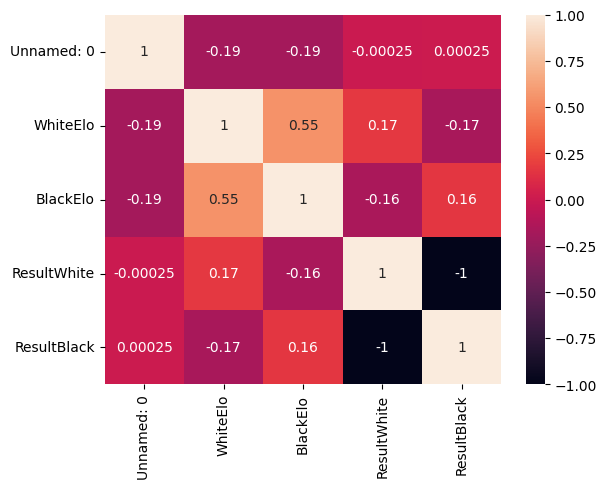

In [49]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Correlação de Pearson entre duas variáveis (duas colunas de dados ou duas pandas' Series):

fonte: https://www.statology.org/correlation-test-in-python/

In [50]:
from scipy.stats.stats import pearsonr

x = df['WhiteElo']
y = df['WhiteElo']

#calculation correlation coefficient and p-value between x and y
pearsonr(x, y)


C:\Users\davib\AppData\Local\Temp\ipykernel_27456\1700313539.py:1: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


PearsonRResult(statistic=np.float64(1.0), pvalue=np.float64(0.0))

# Correlação de Spearman

A correlação de Spearman é utilizada para variáveis que NÃO seguem uma distribuição normal.
Inclusive, pode ser utilizado para variáveis ordinais.

In [51]:
df.corr('spearman', numeric_only=True)

,Unnamed: 0,WhiteElo,BlackElo,ResultWhite,ResultBlack
Unnamed: 0,1.000000,-0.221665,-0.221513,0.000025,-0.000025
WhiteElo,-0.221665,1.000000,0.726598,0.148461,-0.148461
BlackElo,-0.221513,0.726598,1.000000,-0.143276,0.143276
ResultWhite,0.000025,0.148461,-0.143276,1.000000,-1.000000
ResultBlack,-0.000025,-0.148461,0.143276,-1.000000,1.000000


-Mapa de calor: é possível visualizar as correlações em um mapa de calor utilizando a biblioteca Seaborn (sns).

<Axes: >

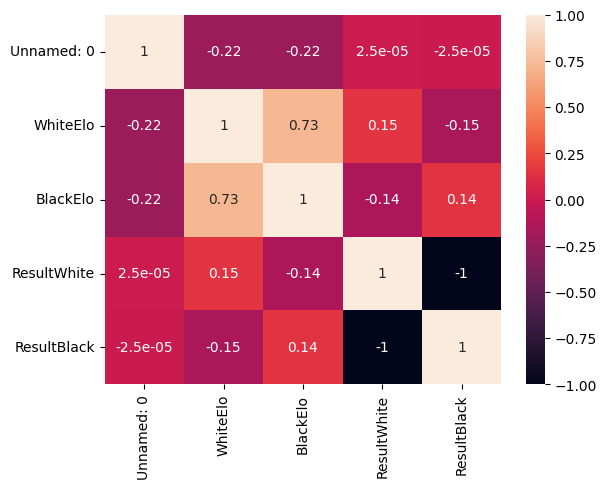

In [55]:
sns.heatmap(df.corr('spearman', numeric_only=True), annot=True)

# Teste t-student de 2 amostras independentes


O teste t-student de 2 amostras independentes verifica se os grupos possuem médias similares (H0, p-value >= 0.05) ou significativamente diferentes (H1, p-value <0.05) em relação à determinada variável.

Por exemplo, é possível comparar a altura do grupo A vs o grupo B. A diferença significativa ocorre quando há pouca sobreposição nas distribuições de altura dos grupos. Neste caso, o grupo A seria "sistematicamente" mais baixo que o grupo B. A imagem abaixo ilustra este exemplo.

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

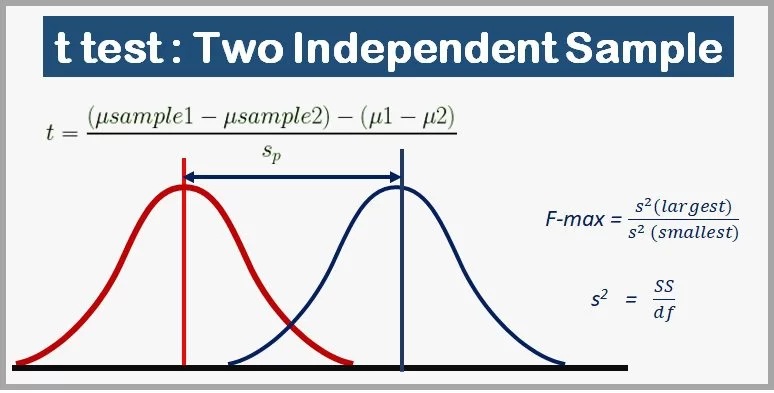

Fonte: https://matistics.com/13-hypothesis-t-test-2-sample/

Documentação scypy:

Parameters:
a, b : array_like
The arrays must have the same shape, except in the dimension corresponding to axis (the first, by default).

axis : int or None, default: 0
If an int, the axis of the input along which to compute the statistic. The statistic of each axis-slice (e.g. row) of the input will appear in a corresponding element of the output. If None, the input will be raveled before computing the statistic.

equal_var : bool, optional
If True (default), perform a standard independent 2 sample test that assumes equal population variances [1]. If False, perform Welch’s t-test, which does not assume equal population variance [2].

Added in version 0.11.0.

nan_policy{‘propagate’, ‘omit’, ‘raise’}
Defines how to handle input NaNs.

propagate: if a NaN is present in the axis slice (e.g. row) along which the statistic is computed, the corresponding entry of the output will be NaN.

omit: NaNs will be omitted when performing the calculation. If insufficient data remains in the axis slice along which the statistic is computed, the corresponding entry of the output will be NaN.

raise: if a NaN is present, a ValueError will be raised.

--------------


result : TtestResult
An object with the following attributes:

statistic : float or ndarray
The t-statistic.

pvalue : float or ndarray
The p-value associated with the given alternative.

df : float or ndarray
The number of degrees of freedom used in calculation of the t-statistic. This is always NaN for a permutation t-test.

In [53]:

import numpy as np
from scipy import stats


amostra1 = [1, 2, 2, 2, 2, 3, 4, 5]
amostra2 = [1, 4, 5, 7, 8, 9, 9]

#T-test with different means, variance, and n:

resultado = stats.ttest_ind(amostra1, amostra2, equal_var=False, alternative='two-sided')

print(resultado)

print("---")
print(f"Estatística Teste t-student = {resultado.statistic}")
print(f"P-valor obtido = {resultado.pvalue}")
print(f"Graus de Liberdade = {resultado.df}")
print("---")

if resultado.pvalue < 0.05:
  print("As amostras apresentam médias significativamente diferentes (p-valor < 0.05). A H0 foi rejeitada.")
else:
  print("As amostras apresentam médias semelhantes. Não foi possível diferenciá-las significativamente. Não foi possível rejeitar H0")


TtestResult(statistic=np.float64(-2.900930150047319), pvalue=np.float64(0.019869473366689813), df=np.float64(7.997680662659852))
---
Estatística Teste t-student = -2.900930150047319
P-valor obtido = 0.019869473366689813
Graus de Liberdade = 7.997680662659852
---
As amostras apresentam médias significativamente diferentes (p-valor < 0.05). A H0 foi rejeitada.


# ANOVA - teste entre várias amostras independentes

O teste ANOVA verifica se há diferenças significativas (H1) entre diversas amostras independentes, isto é, entre diversos grupos independentes.

Fonte: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html#scipy.stats.f_oneway


f_oneway(*samples, axis=0, nan_policy='propagate', keepdims=False)

----

Returns:
statistic: float
The computed F statistic of the test.

pvalue: float
The associated p-value from the F distribution.

In [ ]:
import numpy as np
from scipy.stats import f_oneway

tillamook = [0.0571, 0.0813, 0.0831, 0.0976, 0.0817, 0.0859, 0.0735, 0.0659, 0.0923, 0.0836]
newport = [0.0873, 0.0662, 0.0672, 0.0819, 0.0749, 0.0649, 0.0835, 0.0725]
petersburg = [0.0974, 0.1352, 0.0817, 0.1016, 0.0968, 0.1064, 0.105]
magadan = [0.1033, 0.0915, 0.0781, 0.0685, 0.0677, 0.0697, 0.0764, 0.0689]
tvarminne = [0.0703, 0.1026, 0.0956, 0.0973, 0.1039, 0.1045]

f_oneway(tillamook, newport, petersburg, magadan, tvarminne)


F_onewayResult(statistic=7.121019471642447, pvalue=0.0002812242314534544)

# Kruskal-Wallis - NÃO-paramétrico - várias amostras independentes

O teste de Krsukal-Wallis é a alternativa não paramétrica para comparar vários grupos independentes.
Caso a distribuição da variável não seja normal para os grupos a serem comparados, este teste deve ser utilizado.

Fonte: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html

----

Returns :
statistic
float
The Kruskal-Wallis H statistic, corrected for ties.

pvalue
float
The p-value for the test using the assumption that H has a chi square distribution. The p-value returned is the survival function of the chi square distribution evaluated at H.

In [ ]:
from scipy import stats
x = [1, 3, 5, 7, 9]
y = [2, 4, 6, 8, 10]
stats.kruskal(x, y)
